In [1]:
import sys
sys.path.append('../scripts')
import utils as util
import eda
import plot
import text_analyzer
import publisher_analyzer
import pyLDAvis.gensim_models

Load the cleaned data.

In [2]:
data = util.load_data('../data/cleaned/cleaned_news_data.csv')
data.head(5)


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


Explore the cleaned data and convert the date column datatype to the appropriate one.

In [3]:
preprocess = util.DataPreprocessor
data = preprocess.convert_date_dtype(data)
preprocess.explore_data(data)

Converted 'date' dtype: datetime64[ns, UTC]
Shape of the data: (1407328, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype              
---  ------     --------------    -----              
 0   headline   1407328 non-null  object             
 1   url        1407328 non-null  object             
 2   publisher  1407328 non-null  object             
 3   date       1407328 non-null  datetime64[ns, UTC]
 4   stock      1407328 non-null  object             
dtypes: datetime64[ns, UTC](1), object(4)
memory usage: 53.7+ MB
Info of the data: None


### Descriptive Statistics


In [4]:
eda = eda.EDA


Descriptive statistics for the headlines

In [5]:
eda.get_headline_stats(data)

count                     1407328
unique                     845770
top       Benzinga's Top Upgrades
freq                         5449
Name: headline, dtype: object 

Average Headline Length: 47
Max Headline Length: 512
Min Headline Length: 3
Headline Length Range: 509


### Publication Trends

In [6]:
eda.articles_per_publisher(data)

publisher
Paul Quintaro             228373
Lisa Levin                186979
Benzinga Newsdesk         150484
Charles Gross              96732
Monica Gerson              82380
                           ...  
White Diamond Research         1
Michael Zanger                 1
Stock Market Newz              1
Forexpros.com                  1
Jim Pearce                     1
Length: 1034, dtype: int64

Analyze  publication counts by day, month, and year.

In [7]:
eda.analyze_publication_time(data)

publication_hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
dtype: int64

Here we can gather, the 0th hour or midnight is the most popular publication hour.

In [8]:
plotter = plot.Plot

/Users/hazel/Desktop/Self Study/kiam8/kaim-week-1/notebooks/../scripts/plot.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publication_by_hour.index,


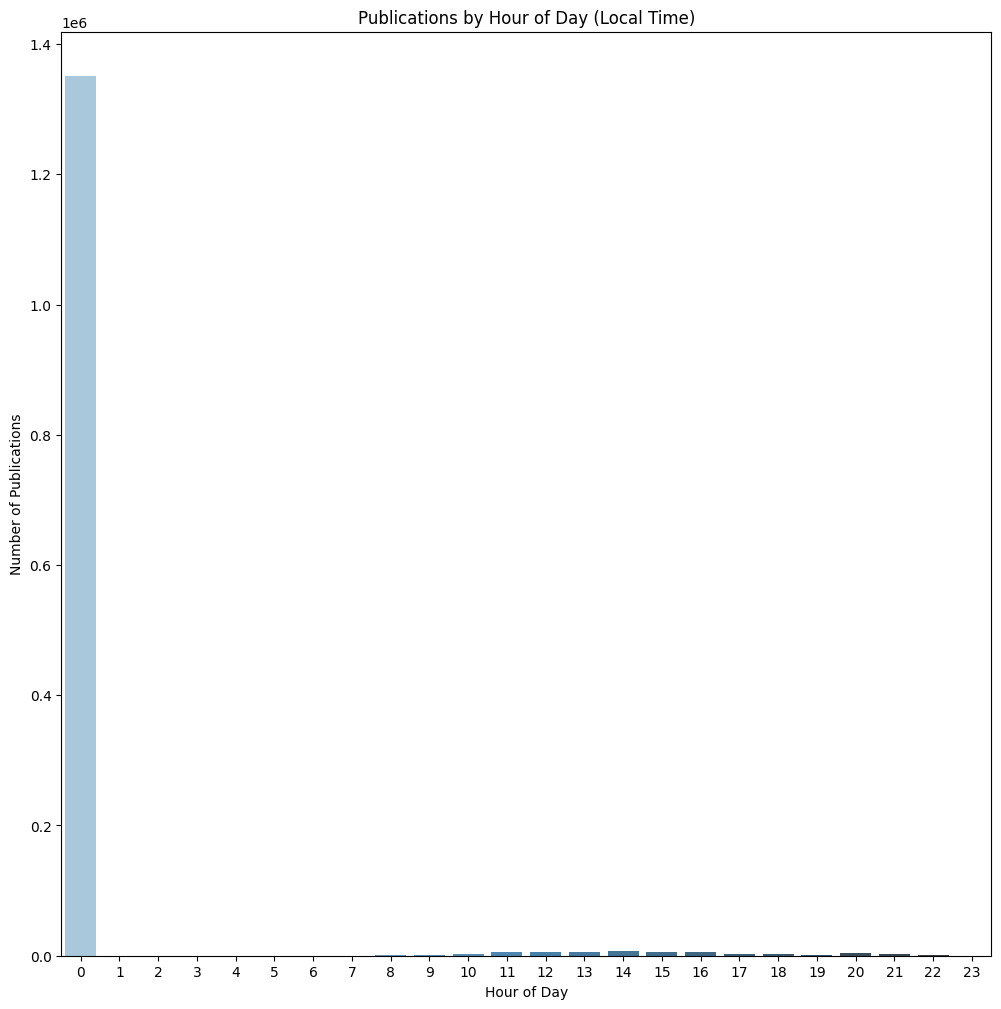

publication_hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
dtype: int64

In [9]:
plotter.plot_hourly_publications(data)

### Time Series Analysis


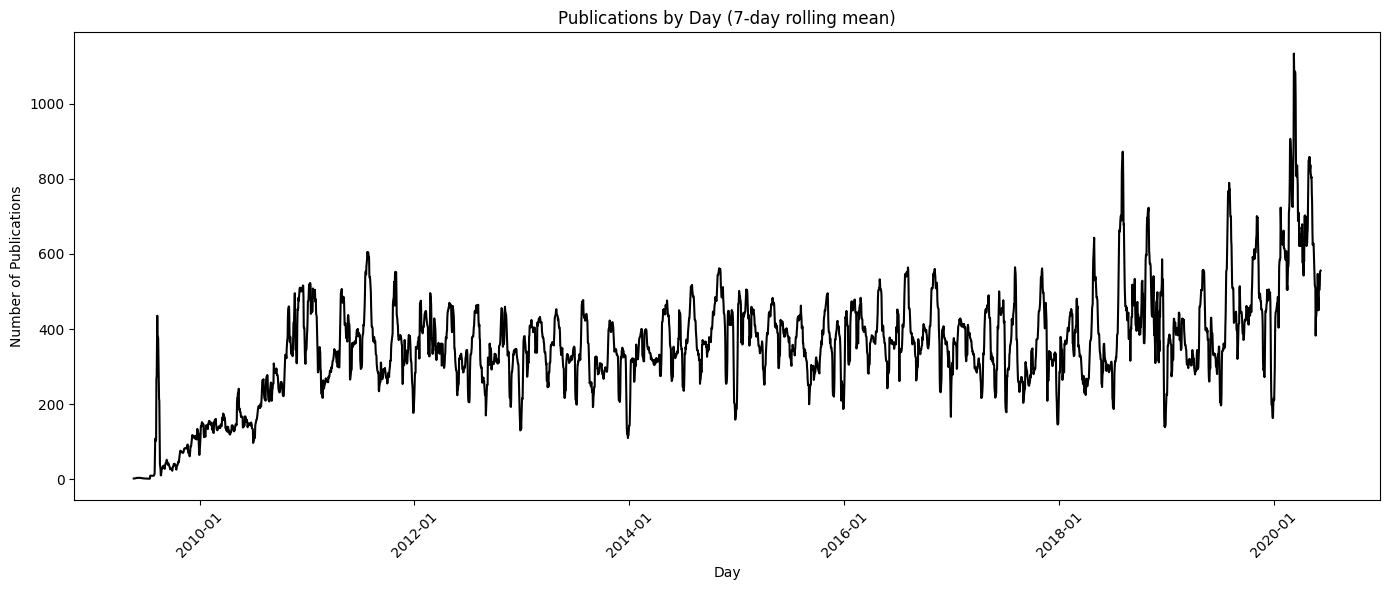

In [10]:
plotter.plot_daily_publications(data)

/Users/hazel/Desktop/Self Study/kiam8/kaim-week-1/notebooks/../scripts/plot.py:39: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  publications_by_month = (data['date'].dt.to_period('M').dt.to_timestamp().value_counts().sort_index()


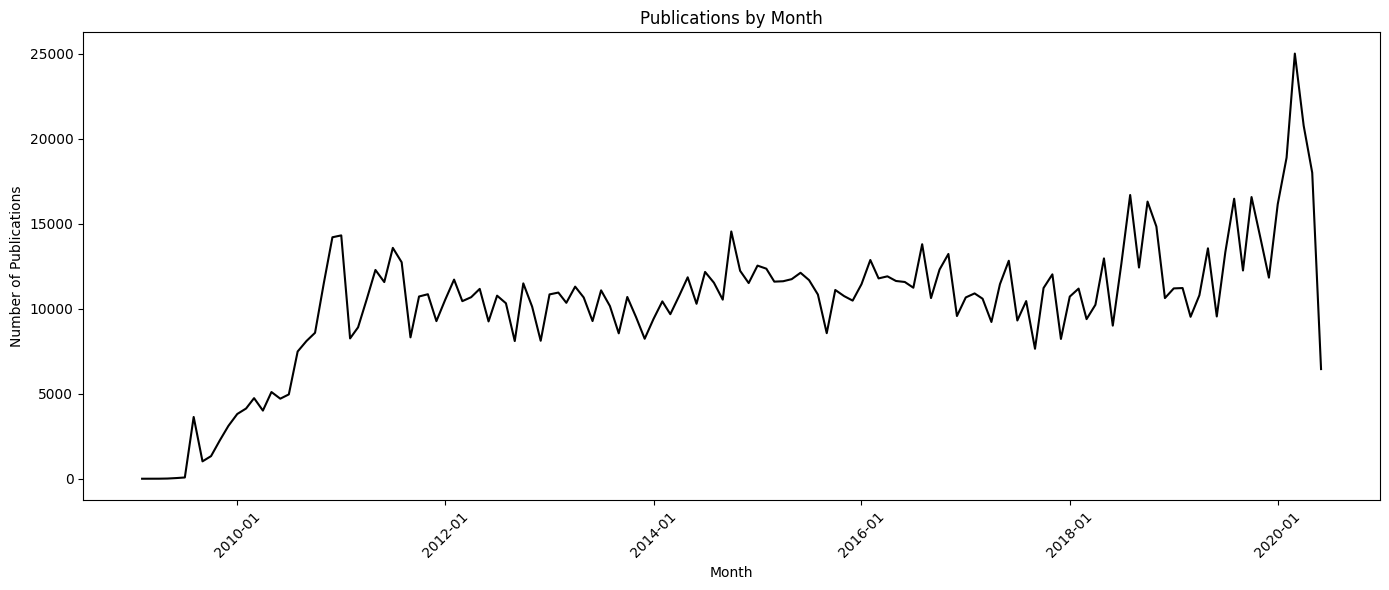

date
2009-02-01        1
2009-04-01        3
2009-05-01       12
2009-06-01       40
2009-07-01       75
              ...  
2020-02-01    18878
2020-03-01    24995
2020-04-01    20757
2020-05-01    17992
2020-06-01     6447
Name: count, Length: 136, dtype: int64

In [11]:
plotter.plot_monthly_publications(data)

/Users/hazel/Desktop/Self Study/kiam8/kaim-week-1/notebooks/../scripts/plot.py:64: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  publications_by_year = (data['date'].dt.to_period('Y').dt.to_timestamp().value_counts().sort_index())


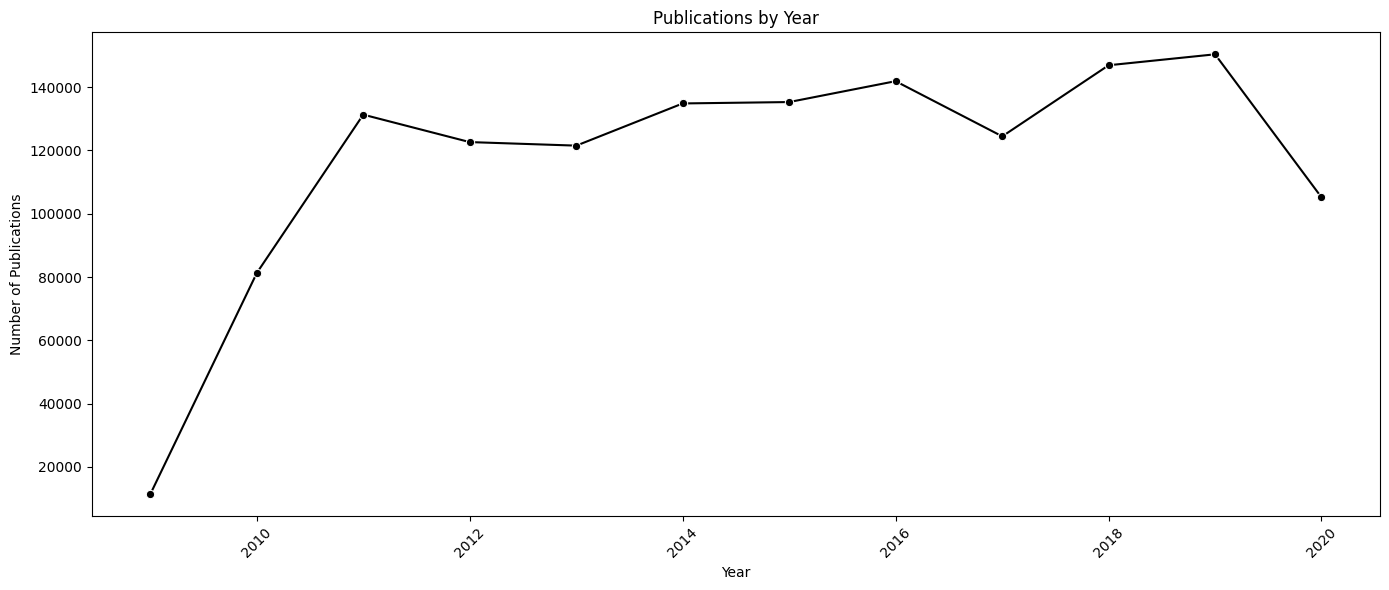

date
2009-01-01     11489
2010-01-01     81319
2011-01-01    131322
2012-01-01    122649
2013-01-01    121529
2014-01-01    134859
2015-01-01    135295
2016-01-01    141892
2017-01-01    124456
2018-01-01    146924
2019-01-01    150380
2020-01-01    105214
Name: count, dtype: int64

In [12]:
plotter.plot_yearly_publications(data)

### Text Analysis (Sentiment analysis & Topic Modeling)

In [16]:
textanaysis = text_analyzer.TextAnalyzer

In [17]:
data_with_sentiment = textanaysis.analyze_headline_sentiment(data)

print(data_with_sentiment[['headline', 'sentiment']].head(10))


                                            headline sentiment
0            Stocks That Hit 52-Week Highs On Friday   neutral
1         Stocks That Hit 52-Week Highs On Wednesday   neutral
2                      71 Biggest Movers From Friday   neutral
3       46 Stocks Moving In Friday's Mid-Day Session   neutral
4  B of A Securities Maintains Neutral on Agilent...  positive
5  CFRA Maintains Hold on Agilent Technologies, L...  negative
6  UBS Maintains Neutral on Agilent Technologies,...   neutral
7  Agilent Technologies shares are trading higher...  positive
8  Wells Fargo Maintains Overweight on Agilent Te...  negative
9         10 Biggest Price Target Changes For Friday   neutral


Here we user the VADER library to assign sentiment scores to the headlines. A numerical compound sentiment score (from −1 to +1) is calculated for each headline and then is classified as positive, negative, or neutral based on standard VADER thresholds.

In [22]:
textanaysis.preprocess_text_spacy(data)
data.head(5)

,headline,url,publisher,date,stock,headline_length,publication_hour,sentiment_score,sentiment,publisher_domain,processed_headline
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39,14,0.000,neutral,None,stock hit 52 week high friday
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42,14,0.000,neutral,None,stock hit 52 week high wednesday
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,29,8,0.000,neutral,None,71 big mover friday
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,44,16,0.000,neutral,None,46 stock move friday mid day session
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,87,15,0.296,positive,None,b security maintain neutral agilent technology...


In [23]:
textanaysis.apply_lda(data, num_topics=10)


LDA Topics:
(0, '0.225*"$" + 0.079*"m" + 0.061*"vs" + 0.044*"sale" + 0.043*"est"')
(1, '0.064*"announce" + 0.037*"initiate" + 0.032*"coverage" + 0.023*"share" + 0.023*"energy"')
(2, '0.129*"etf" + 0.048*"check" + 0.044*"new" + 0.041*"xle" + 0.038*"vpu"')
(3, '0.043*"option" + 0.042*"big" + 0.033*"alert" + 0.029*"mover" + 0.027*"trade"')
(4, '0.027*"analyst" + 0.022*"food" + 0.017*"pick" + 0.016*"offer" + 0.016*"health"')
(5, '0.053*"stock" + 0.050*"benzinga" + 0.046*"week" + 0.035*"earning" + 0.031*"industrial"')
(6, '0.060*"market" + 0.050*"mid" + 0.048*"update" + 0.043*"day" + 0.030*"morning"')
(7, '0.044*"sector" + 0.040*"share" + 0.033*"energy" + 0.031*"trade" + 0.030*"market"')
(8, '0.037*"retail" + 0.031*"say" + 0.028*"pro" + 0.027*"tech" + 0.020*"0.2"')
(9, '0.094*"$" + 0.051*"pt" + 0.046*"buy" + 0.039*"downgrade" + 0.038*"raise"')


(<gensim.models.ldamodel.LdaModel at 0x3228dc080>,
 [(0, '0.225*"$" + 0.079*"m" + 0.061*"vs" + 0.044*"sale" + 0.043*"est"'),
  (1,
   '0.064*"announce" + 0.037*"initiate" + 0.032*"coverage" + 0.023*"share" + 0.023*"energy"'),
  (2, '0.129*"etf" + 0.048*"check" + 0.044*"new" + 0.041*"xle" + 0.038*"vpu"'),
  (3,
   '0.043*"option" + 0.042*"big" + 0.033*"alert" + 0.029*"mover" + 0.027*"trade"'),
  (4,
   '0.027*"analyst" + 0.022*"food" + 0.017*"pick" + 0.016*"offer" + 0.016*"health"'),
  (5,
   '0.053*"stock" + 0.050*"benzinga" + 0.046*"week" + 0.035*"earning" + 0.031*"industrial"'),
  (6,
   '0.060*"market" + 0.050*"mid" + 0.048*"update" + 0.043*"day" + 0.030*"morning"'),
  (7,
   '0.044*"sector" + 0.040*"share" + 0.033*"energy" + 0.031*"trade" + 0.030*"market"'),
  (8,
   '0.037*"retail" + 0.031*"say" + 0.028*"pro" + 0.027*"tech" + 0.020*"0.2"'),
  (9,
   '0.094*"$" + 0.051*"pt" + 0.046*"buy" + 0.039*"downgrade" + 0.038*"raise"')],
 <gensim.corpora.dictionary.Dictionary at 0x17f765ac0>)

### Publisher Analysis

The number of articles published by each publisher in descending order.

In [18]:
publsheranalysis = publisher_analyzer.PublisherAnalysis

In [19]:
publsheranalysis.get_publisher_counts(data)


Top 10 publishers:
 publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [20]:
publsheranalysis.get_publisher_sentiment_distribution(data_with_sentiment)


Sentiment distribution for top 10 publishers:


sentiment,negative,neutral,positive
publisher,,,
47ertrends,0.000000,1.000000,0.000000
AARP,0.000000,1.000000,0.000000
ABNNewswire,0.307692,0.307692,0.384615
Aakin,0.000000,0.600000,0.400000
Aaron Jackson.Ed,0.062500,0.000000,0.937500
...,...,...,...
vic@forextraininggroup.com,0.000000,1.000000,0.000000
vishwanath@benzinga.com,0.468306,0.363388,0.168306
vivek.proactive@gmail.com,0.375000,0.475000,0.150000


In [21]:
publsheranalysis.extract_publisher_domains(data)


Top email domains:
 publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64
